In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import gzip
from scipy.stats import ttest_ind
from matplotlib_venn import venn2
from matplotlib_venn import venn3
import seaborn as sns
import gseapy as gp
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# DEG 분석
- 두 조건 사이에서 생물학적으로 의미 있게 변한 유전자

### GSE138518 -> DEG 분석

- 데이터가 적어서 pvalue랑 logFC로 필터링하면 유전자가 하나도 안 남음 -> Score로 중요도 판단

In [2]:
# 1. 데이터 불러오기
df = pd.read_excel("GSE138518_RNA.xlsx")

# gene symbol 기준
df = df.set_index("SYMBOL")

# 2. count 데이터 선택
count_cols = ["N20","N21","N25","P14","P15","P16"]
counts = df[count_cols]
# 중복 gene 제거 (평균 사용)
counts = counts.groupby(counts.index).mean()

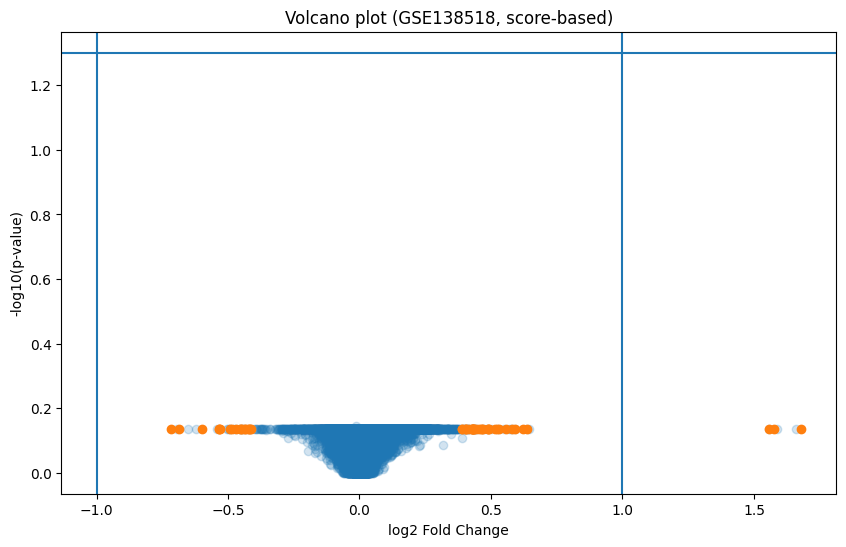

Top genes (score 기준):
              gene      pval     logFC     score  -log10(pval)
2670           HBB  0.731872  1.679071  0.227623      0.135565
3214          HBA1  0.731872  1.576422  0.213707      0.135565
3243          HBA2  0.731872  1.555576  0.210881      0.135565
32691          H19  0.731872 -0.717633  0.097286      0.135565
32906  RPS10-NUDT3  0.731872 -0.685159  0.092883      0.135565
3489      MTND1P23  0.731872  0.638581  0.086569      0.135565
21             VCL  0.731872  0.623172  0.084480      0.135565
32075         IER2  0.731872 -0.598990  0.081202      0.135565
610           BRD3  0.731872  0.592822  0.080366      0.135565
2180         RUNX1  0.731872  0.578054  0.078364      0.135565
963            LUM  0.731872  0.555262  0.075274      0.135565
31005      CACNA1H  0.731872 -0.534602  0.072473      0.135565
31698        NEAT1  0.731872 -0.534273  0.072429      0.135565
4775       ADAMTS1  0.731872  0.530691  0.071943      0.135565
32760          MVD  0.731872 -0.5

In [ ]:
# 3. AnnData 생성
adata = sc.AnnData(counts.T)

# 그룹 정보
adata.obs['condition'] = ['Normal','Normal','Normal','PCOS','PCOS','PCOS']

# 4. normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 5. DEG 분석 (t-test)
sc.tl.rank_genes_groups(
    adata,
    groupby='condition',
    method='t-test'
)

# 6. DEG 결과 추출
result = adata.uns['rank_genes_groups']

deg = pd.DataFrame({
    'gene': result['names']['PCOS'],
    'pval': result['pvals_adj']['PCOS']
})

# p-value 0 방지
deg['pval'] = deg['pval'].replace(0, 1e-300)

# 7. logFC 직접 계산
mean_pcos = counts[['P14','P15','P16']].mean(axis=1)
mean_normal = counts[['N20','N21','N25']].mean(axis=1)

logFC = np.log2((mean_pcos + 1) / (mean_normal + 1))

deg['logFC'] = deg['gene'].map(logFC)

# nan 제거
deg = deg.dropna()

# 8. score 계산
deg['score'] = -np.log10(deg['pval']) * abs(deg['logFC'])

# 9. volcano plot 준비
deg['-log10(pval)'] = -np.log10(deg['pval'])

# score 상위 gene 선택
top_n = 50
top_genes = deg.sort_values('score', ascending=False).head(top_n)
top_set = set(top_genes['gene'])

# 10. volcano plot
plt.figure(figsize=(10,6))

# 전체 (jitter 추가로 겹침 해결)
plt.scatter(
    deg['logFC'] + np.random.normal(0, 0.02, len(deg)),
    deg['-log10(pval)'],
    alpha=0.2
)

# 상위 gene 강조
highlight = deg['gene'].isin(top_set)

plt.scatter(
    deg[highlight]['logFC'],
    deg[highlight]['-log10(pval)']
)

# 기준선
plt.axvline(1)
plt.axvline(-1)
plt.axhline(-np.log10(0.05))

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano plot (GSE138518, score-based)")

plt.show()

# 11. 상위 gene 확인
print("Top genes (score 기준):")
print(top_genes.head(20))

# 13. 저장 (다음 단계용)
deg.to_csv("GSE138518_DEG_all.csv", index=False)
top_genes.to_csv("GSE138518_top50_score.csv", index=False)

### GSE155489 -> (gene mapping) -> DEG 분석

In [3]:
# 데이터 가져오기
gc = pd.read_csv("./GSE155489/GSE155489_gc_pcos_counts.csv.gz")
gv = pd.read_csv("./GSE155489/GSE155489_gv_pcos_counts.csv.gz")

# gene column index로 설정
gv = gv.set_index('gene')
gc = gc.set_index('gene')

# 깨진 gene 제거
gv = gv[~gv.index.str.contains(r'^\d+-')]
gc = gc[~gc.index.str.contains(r'^\d+-')]

# 숫자로 시작하는 것도 제거
gv = gv[gv.index.str.match(r'^[A-Za-z]')]
gc = gc[gc.index.str.match(r'^[A-Za-z]')]

# 데이터 숫자로 변환
gv = gv.apply(pd.to_numeric, errors='coerce')
gc = gc.apply(pd.to_numeric, errors='coerce')

In [4]:
# 1. gz 파일 열기 (gc, gv 라벨링용 데이터)
with gzip.open("GSE155489/GSE155489_series_matrix.txt.gz", 'rt') as f:
    lines = f.readlines()

# 2. 필요한 행 찾기
sample_title_line = [l for l in lines if l.startswith('!Sample_title')][0]
sample_geo_line = [l for l in lines if l.startswith('!Sample_geo_accession')][0]
sample_desc_line = [l for l in lines if l.startswith('!Sample_description')][0]

# 3. 탭으로 분리
sample_titles = sample_title_line.strip().split('\t')[1:]  # 첫 번째는 '!Sample_title'
sample_geo = sample_geo_line.strip().split('\t')[1:]
sample_desc = sample_desc_line.strip().split('\t')[1:]

# 4. meta_df 만들기
meta_df = pd.DataFrame({
    "Sample_geo_accession": sample_geo,
    "Sample_title": sample_titles,
    "Sample_description": sample_desc
})

meta_df['Sample_geo_accession'] = meta_df['Sample_geo_accession'].str.strip('"')
meta_df['Sample_title'] = meta_df['Sample_title'].str.strip('"')
meta_df['Sample_description'] = meta_df['Sample_description'].str.strip('"')

meta_df.head(5)

,Sample_geo_accession,Sample_title,Sample_description
0,GSM4705187,oocyte-Control_1,GV_A2
1,GSM4705188,oocyte-Control_2,GV_A3
2,GSM4705189,oocyte-Control_3,GV_A40
3,GSM4705190,oocyte-Control_4,GV_A41
4,GSM4705191,oocyte-Control_5,GV_A27


In [5]:
# 열 이름 바꾸기
rename_dict = {desc: title for desc, title in zip(meta_df['Sample_description'], meta_df['Sample_title'])}

gc = gc.rename(columns=rename_dict)
gv = gv.rename(columns=rename_dict)

In [6]:
gv

,oocyte-PCOS_1,oocyte-PCOS_2,oocyte-PCOS_3,oocyte-PCOS_4,oocyte-PCOS_5,oocyte-PCOS_6,oocyte-Control_1,oocyte-Control_2,oocyte-Control_5,oocyte-Control_6,oocyte-Control_3,oocyte-Control_4
gene,,,,,,,,,,,,
A1BG,23,17,17,25,57,14,22,23,15,10,17,14
A1BG-AS1,19,13,30,24,69,14,28,39,19,8,12,15
A1CF,477,413,374,283,1362,591,374,471,471,493,233,249
A2M,0,0,0,0,0,0,0,0,0,0,0,0
A2M-AS1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11AP1,1,4,0,2,6,1,5,1,2,1,1,0
ZYG11B,8,3,7,9,9,3,8,6,16,7,8,2
ZYX,43,57,72,77,87,34,76,87,17,26,7,5


In [89]:
# DEG_gv
# 그룹 나누기
pcos_cols = [col for col in gv.columns if "PCOS" in col]
control_cols = [col for col in gv.columns if "Control" in col]

print("PCOS:", len(pcos_cols))
print("Control:", len(control_cols))

# logFC 계산
mean_pcos = gv[pcos_cols].mean(axis=1)
mean_control = gv[control_cols].mean(axis=1)

logFC = np.log2(mean_pcos + 1) - np.log2(mean_control + 1)

# p-value 계산
pvals = []

for gene in gv.index:
    p = ttest_ind(
        gv.loc[gene, pcos_cols],
        gv.loc[gene, control_cols],
        equal_var=False
    ).pvalue
    pvals.append(p)

# DEG 테이블
deg_gv = pd.DataFrame({
    "gene": gv.index,
    "logFC": logFC,
    "pval": pvals
})

deg_gv["-log10(pval)"] = -np.log10(deg_gv["pval"] + 1e-300)

# DEG 필터링
deg_gv_filtered = deg_gv[
    (abs(deg_gv["logFC"]) > 1) &
    (deg_gv["pval"] < 0.05)
]

print("DEG 개수:", len(deg_gv_filtered))

# 저장
deg_gv.to_csv("GV_ALL_DEG.csv", index=False)
deg_gv_filtered.to_csv("GV_DEG.csv", index=False)

PCOS: 6
Control: 6


c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWar

DEG 개수: 3374


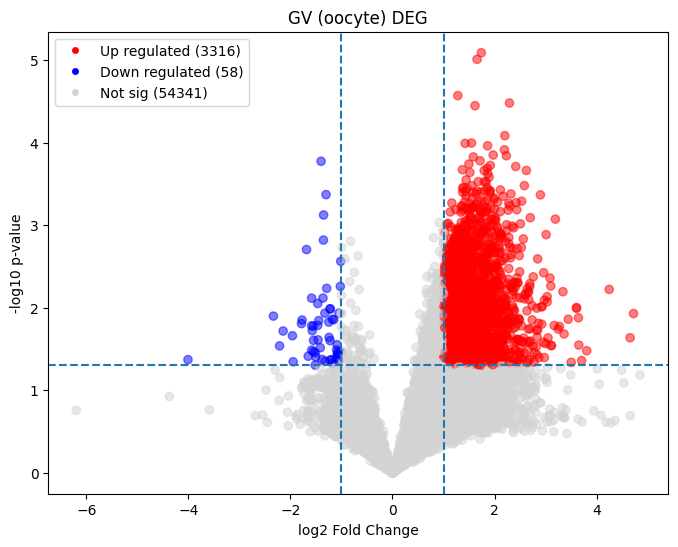

In [90]:
# volcano plot
fc_cutoff = 1
p_cutoff = 0.05

# 기본 색: lightgray
deg_gv["color"] = "lightgray"

# up-regulated (빨강)
deg_gv.loc[
    (deg_gv["logFC"] > fc_cutoff) & (deg_gv["pval"] < p_cutoff),
    "color"
] = "red"

# down-regulated (파랑)
deg_gv.loc[
    (deg_gv["logFC"] < -fc_cutoff) & (deg_gv["pval"] < p_cutoff),
    "color"
] = "blue"

up_count = (deg_gv["color"] == "red").sum()
down_count = (deg_gv["color"] == "blue").sum()
ns_count = (deg_gv["color"] == "lightgray").sum()

plt.figure(figsize=(8,6))

plt.scatter(
    deg_gv["logFC"],
    deg_gv["-log10(pval)"],
    c=deg_gv["color"],
    alpha=0.5
)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Up regulated ({up_count})',
           markerfacecolor='red', markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label=f'Down regulated ({down_count})',
           markerfacecolor='blue', markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label=f'Not sig ({ns_count})',
           markerfacecolor='lightgray', markersize=6)
]

plt.legend(handles=legend_elements, loc='upper left')

# 기준선
plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("GV (oocyte) DEG")

plt.show()

In [91]:
# DEG_gc
# 그룹 나누기
pcos_cols_gc = [col for col in gc.columns if "PCOS" in col]
control_cols_gc = [col for col in gc.columns if "Control" in col]

print("PCOS:", len(pcos_cols_gc))
print("Control:", len(control_cols_gc))

# logFC 계산
mean_pcos_gc = gc[pcos_cols_gc].mean(axis=1)
mean_control_gc = gc[control_cols_gc].mean(axis=1)

logFC = np.log2(mean_pcos_gc + 1) - np.log2(mean_control_gc + 1)

# p-value 계산
pvals = []

for gene in gc.index:
    p = ttest_ind(
        gc.loc[gene, pcos_cols_gc],
        gc.loc[gene, control_cols_gc],
        equal_var=False
    ).pvalue
    pvals.append(p)

# DEG 테이블
deg_gc = pd.DataFrame({
    "gene": gc.index,
    "logFC": logFC,
    "pval": pvals
})

deg_gc["-log10(pval)"] = -np.log10(deg_gc["pval"] + 1e-300)

# DEG 필터링
deg_gc_filtered = deg_gc[
    (abs(deg_gc["logFC"]) > 1) &
    (deg_gc["pval"] < 0.05)
]

print("DEG 개수:", len(deg_gc_filtered))

# 저장
deg_gc.to_csv("GC_ALL_DEG.csv", index=False)
deg_gc_filtered.to_csv("GC_DEG.csv", index=False)

PCOS: 4
Control: 4


c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\OK\anaconda3\envs\gsea\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWar

DEG 개수: 1573


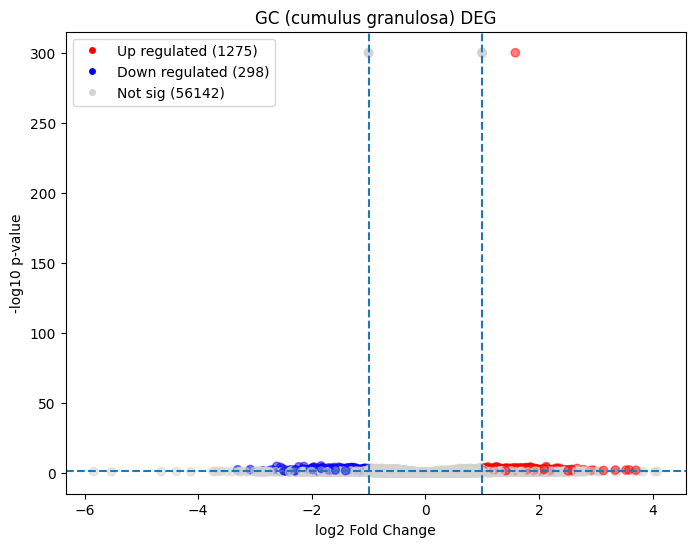

In [92]:
# volcano plot
fc_cutoff = 1
p_cutoff = 0.05

# 기본 색: lightgray
deg_gc["color"] = "lightgray"

# up-regulated (빨강)
deg_gc.loc[
    (deg_gc["logFC"] > fc_cutoff) & (deg_gc["pval"] < p_cutoff),
    "color"
] = "red"

# down-regulated (파랑)
deg_gc.loc[
    (deg_gc["logFC"] < -fc_cutoff) & (deg_gc["pval"] < p_cutoff),
    "color"
] = "blue"

up_count = (deg_gc["color"] == "red").sum()
down_count = (deg_gc["color"] == "blue").sum()
ns_count = (deg_gc["color"] == "lightgray").sum()

plt.figure(figsize=(8,6))

plt.scatter(
    deg_gc["logFC"],
    deg_gc["-log10(pval)"],
    c=deg_gc["color"],
    alpha=0.5
)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Up regulated ({up_count})',
           markerfacecolor='red', markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label=f'Down regulated ({down_count})',
           markerfacecolor='blue', markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label=f'Not sig ({ns_count})',
           markerfacecolor='lightgray', markersize=6)
]

plt.legend(handles=legend_elements, loc='upper left')

# 기준선
plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("GC (cumulus granulosa) DEG")

plt.show()

##### GC+GV로 DEG

In [93]:
# GC + combined 합치기
combined = pd.concat([gc, gv], axis=1)

# 그룹 정의
PCOS = [col for col in combined.columns if "PCOS" in col]
Control = [col for col in combined.columns if "Control" in col]

# logFC 계산
mean_pcos = combined[PCOS].mean(axis=1)
mean_control = combined[Control].mean(axis=1)

logFC = np.log2(mean_pcos + 1) - np.log2(mean_control + 1)

# p-value 계산
pvals = []

for gene in combined.index:
    p = ttest_ind(
        combined.loc[gene, PCOS],
        combined.loc[gene, Control],
        equal_var=False
    ).pvalue
    pvals.append(p)

# DEG 테이블
deg_combined = pd.DataFrame({
    "gene": combined.index,
    "logFC": logFC,
    "pval": pvals
})

deg_combined["-log10(pval)"] = -np.log10(deg_combined["pval"] + 1e-300)

# DEG 필터링
deg_combined_filtered = deg_combined[
    (abs(deg_combined["logFC"]) > 1) &
    (deg_combined["pval"] < 0.05)
]

print("DEG 개수:", len(deg_combined_filtered))

# 저장
deg_combined.to_csv("COMBINED_ALL_DEG.csv", index=False)


DEG 개수: 1152


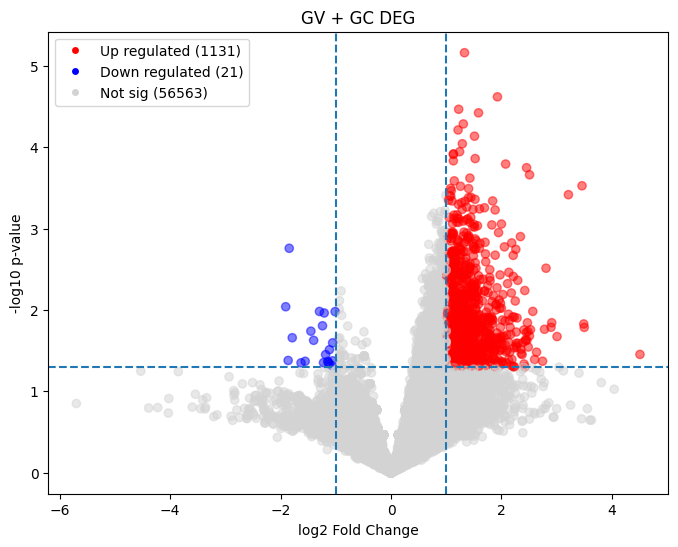

In [94]:
# volcano plot
fc_cutoff = 1
p_cutoff = 0.05

# 기본 색: lightgray
deg_combined["color"] = "lightgray"

# up-regulated (빨강)
deg_combined.loc[
    (deg_combined["logFC"] > fc_cutoff) & (deg_combined["pval"] < p_cutoff),
    "color"
] = "red"

# down-regulated (파랑)
deg_combined.loc[
    (deg_combined["logFC"] < -fc_cutoff) & (deg_combined["pval"] < p_cutoff),
    "color"
] = "blue"

up_count = (deg_combined["color"] == "red").sum()
down_count = (deg_combined["color"] == "blue").sum()
ns_count = (deg_combined["color"] == "lightgray").sum()

plt.figure(figsize=(8,6))

plt.scatter(
    deg_combined["logFC"],
    deg_combined["-log10(pval)"],
    c=deg_combined["color"],
    alpha=0.5
)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'Up regulated ({up_count})',
           markerfacecolor='red', markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label=f'Down regulated ({down_count})',
           markerfacecolor='blue', markersize=6),

    Line2D([0], [0], marker='o', color='w',
           label=f'Not sig ({ns_count})',
           markerfacecolor='lightgray', markersize=6)
]

plt.legend(handles=legend_elements, loc='upper left')

# 기준선
plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("GV + GC DEG")

plt.show()

# DEG 비교
- GSE138518: scanpy rank_genes_groups
- GSE155489: 직접 t-test + logFC 계산

In [95]:
# 1. 첫 번째 DEG: 직접 t-test
deg1 = deg_combined_filtered[['gene','logFC','pval']].copy()
deg1 = deg1.set_index('gene')

# 2. 두 번째 DEG: scanpy rank_genes_groups
result = adata.uns['rank_genes_groups']

deg2 = pd.DataFrame({
    'gene': result['names']['PCOS'],
    'pval': result['pvals_adj']['PCOS']
})
deg2['logFC'] = deg2['gene'].map(logFC)  # logFC 직접 계산한 Series 사용
deg2 = deg2.dropna()
deg2 = deg2.set_index('gene')

# 3. DEG 비교
# 공통 유전자
common_genes = deg1.index.intersection(deg2.index)

deg1_common = deg1.loc[common_genes]
deg2_common = deg2.loc[common_genes]

# logFC 차이 계산
deg_fc_diff = deg1_common['logFC'] - deg2_common['logFC']

# p-value 차이 계산
deg_pval_diff = deg1_common['pval'] - deg2_common['pval']

# 4. 결과 확인
comparison = pd.DataFrame({
    'logFC_deg1': deg1_common['logFC'],
    'logFC_deg2': deg2_common['logFC'],
    'logFC_diff': deg_fc_diff,
    'pval_deg1': deg1_common['pval'],
    'pval_deg2': deg2_common['pval'],
    'pval_diff': deg_pval_diff
})

print("공통 DEG 수:", len(common_genes))
print(comparison.head(20))

# 5. 일치 확인
# logFC 방향이 같은지
comparison['logFC_same_direction'] = np.sign(comparison['logFC_deg1']) == np.sign(comparison['logFC_deg2'])
print("logFC 방향 일치 비율:", comparison['logFC_same_direction'].mean())

# CSV로 저장 가능
# comparison.to_csv("DEG_comparison_deg1_vs_deg2.csv")

공통 DEG 수: 910
          logFC_deg1  logFC_deg2  logFC_diff  pval_deg1  pval_deg2  pval_diff
gene                                                                         
ICA1        1.302628    1.302628         0.0   0.047451   0.930766  -0.883314
ARHGAP33    1.305292    1.305292         0.0   0.001233   0.832870  -0.831637
ITGA3       1.469485    1.469485         0.0   0.011751   0.876990  -0.865239
MATK        1.058894    1.058894         0.0   0.002801   0.760529  -0.757728
TEAD3       1.694557    1.694557         0.0   0.005811   0.731872  -0.726061
DPF1        1.190864    1.190864         0.0   0.022155   0.731872  -0.709717
ZC3H3       1.333750    1.333750         0.0   0.008094   0.977205  -0.969111
AGPAT4      1.512285    1.512285         0.0   0.000073   0.731872  -0.731799
TNFRSF1B    1.558245    1.558245         0.0   0.011724   0.731872  -0.720149
POU2F2      1.346176    1.346176         0.0   0.002969   0.943495  -0.940525
ANK1        1.371969    1.371969         0.0   0.0

# DEG venn diagram

In [131]:
# GSE138518와 GSE155489의 DEG 분석 결과의 교집합

# 데이터 불러오기
deg_138518 = pd.read_csv("GSE138518_DEG_all.csv")
deg_gc = pd.read_csv("GC_DEG.csv")
deg_gv = pd.read_csv("GV_DEG.csv")

# 공통 DEG (GC 기준)
common_gc = set(deg_138518["gene"]) & set(deg_gc["gene"])

common_gc_df = deg_gc[deg_gc["gene"].isin(common_gc)]
common_gc_df.to_csv("common_GC_DEG.csv", index=False)

print("GC 공통 DEG:", len(common_gc))

# 공통 DEG (GV 기준)
common_gv = set(deg_138518["gene"]) & set(deg_gv["gene"])

common_gv_df = deg_gv[deg_gv["gene"].isin(common_gv)]
common_gv_df.to_csv("common_GV_DEG.csv", index=False)

print("GV 공통 DEG:", len(common_gv))

GC 공통 DEG: 1215
GV 공통 DEG: 2930


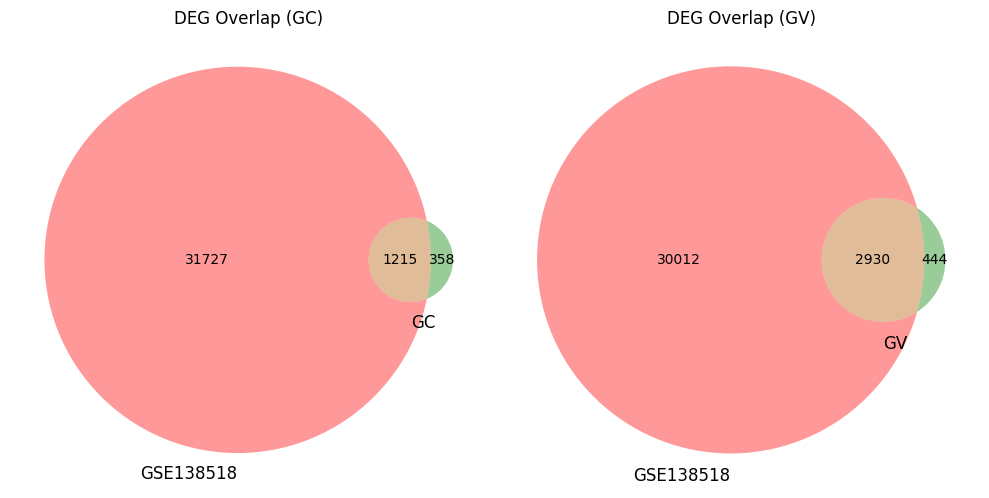

In [ ]:
# gene set 생성
set_138518 = set(deg_138518["gene"])
set_gc = set(deg_gc["gene"])
set_gv = set(deg_gv["gene"])

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# GC Venn
v1 = venn2(
    [set_138518, set_gc],
    set_labels=("GSE138518", "GC"),
    ax=axes[0]
)
axes[0].set_title("DEG Overlap (GC)")

# GV Venn
v2 = venn2(
    [set_138518, set_gv],
    set_labels=("GSE138518", "GV"),
    ax=axes[1]
)
axes[1].set_title("DEG Overlap (GV)")

plt.tight_layout()
plt.show()

3-way 공통 DEG: 127


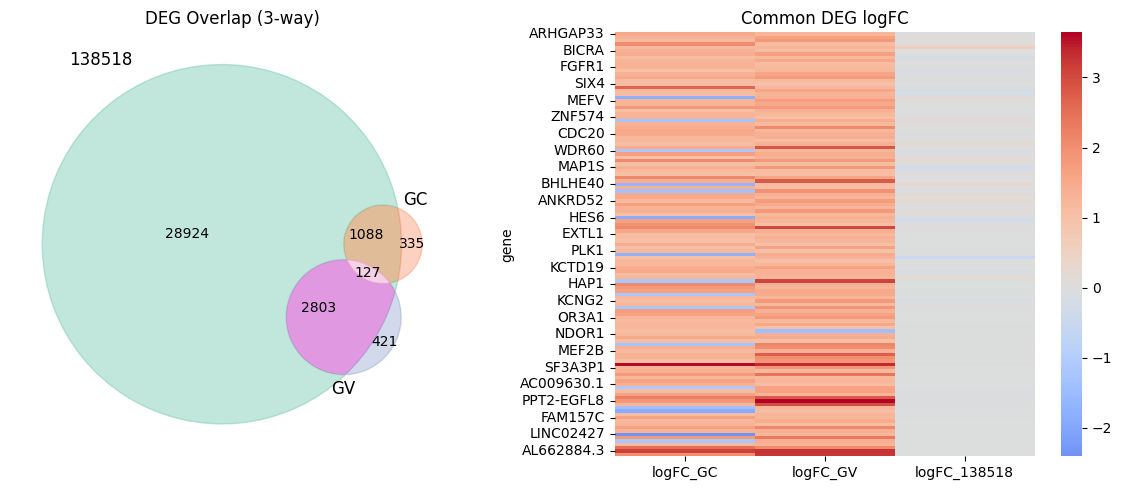

In [ ]:
# 3-way 교집합
common_all = set_138518 & set_gc & set_gv
print("3-way 공통 DEG:", len(common_all))

# heatmap용 데이터 (logFC 기준)
# gene + logFC만 사용
df_gc = deg_gc[deg_gc["gene"].isin(common_all)][["gene", "logFC"]]
df_gv = deg_gv[deg_gv["gene"].isin(common_all)][["gene", "logFC"]]
df_138 = deg_138518[deg_138518["gene"].isin(common_all)][["gene", "logFC"]]

# merge
merged = df_gc.merge(df_gv, on="gene", suffixes=("_GC", "_GV"))
merged = merged.merge(df_138, on="gene")
merged = merged.rename(columns={"logFC": "logFC_138518"})

merged = merged.set_index("gene")

# subplot 시작
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Venn diagram
v = venn3(
    [set_138518, set_gc, set_gv],
    set_labels=("138518", "GC", "GV"),
    ax=axes[0]
)

axes[0].set_title("DEG Overlap (3-way)")

# 색상 (선택)
v.get_patch_by_id('100').set_color('#66c2a5')
v.get_patch_by_id('010').set_color('#fc8d62')
v.get_patch_by_id('001').set_color('#8da0cb')
v.get_patch_by_id('111').set_color('#e78ac3')

# Heatmap
sns.heatmap(
    merged,
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)

axes[1].set_title("Common DEG logFC")

plt.tight_layout()
plt.show()

- 3 dataset에서 공통인 유전자 127개는 중요한 타겟 유전자 후보일 수 있음
- heatmap에서 빨강은 PCOS환자에서 많이 발현된 유전자 / 파랑은 적게 발현된 유전자

In [134]:
# 교집합 gene
set_138 = set(deg_138518["gene"])
set_gc = set(deg_gc["gene"])
set_gv = set(deg_gv["gene"])

common_all = set_138 & set_gc & set_gv
print("3-way 공통 DEG:", len(common_all))

# 필요한 컬럼만 추출 (컬럼명 꼭 확인!!)
df_138 = deg_138518[deg_138518["gene"].isin(common_all)][["gene", "logFC", "pval"]]
df_gc = deg_gc[deg_gc["gene"].isin(common_all)][["gene", "logFC", "pval"]]
df_gv = deg_gv[deg_gv["gene"].isin(common_all)][["gene", "logFC", "pval"]]

# 컬럼 이름 변경
df_138 = df_138.rename(columns={
    "logFC": "logFC_138",
    "pval": "p_138"
})

df_gc = df_gc.rename(columns={
    "logFC": "logFC_GC",
    "pval": "p_GC"
})

df_gv = df_gv.rename(columns={
    "logFC": "logFC_GV",
    "pval": "p_GV"
})

# merge (gene 기준)
merged = df_138.merge(df_gc, on="gene")
merged = merged.merge(df_gv, on="gene")

# 정렬 (선택)
merged = merged.sort_values(by="p_138")

# 저장
merged.to_csv("common_3way_DEG.csv", index=False)

print("저장 완료: common_3way_DEG.csv")

3-way 공통 DEG: 127
저장 완료: common_3way_DEG.csv


##### GC + GV

In [56]:
# 데이터 불러오기
GSE138518 = pd.read_excel("GSE138518_RNA.xlsx")
GSE138518 = GSE138518.set_index("SYMBOL")
count_cols = ["N20","N21","N25","P14","P15","P16"]
GSE138518_counts = GSE138518[count_cols]

deg_1 = pd.read_csv("GSE138518_DEG_all.csv")
deg_2 = pd.read_csv("COMBINED_ALL_DEG.csv")

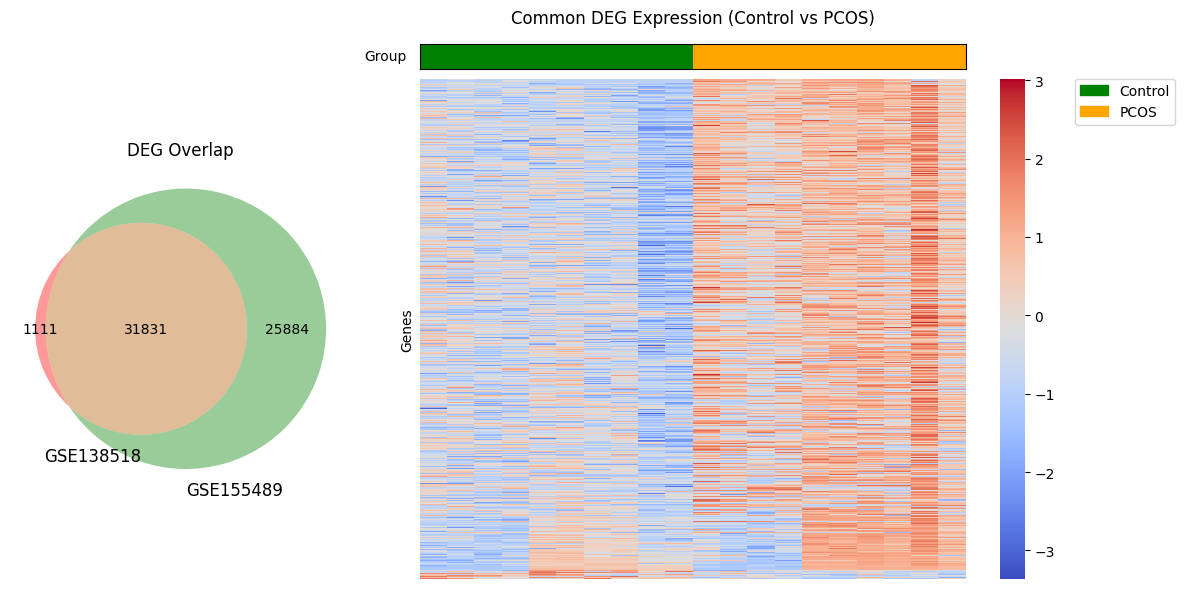

In [70]:
# 데이터 불러오기
deg_1 = pd.read_csv("GSE138518_DEG_all.csv")
deg_2 = pd.read_csv("COMBINED_ALL_DEG.csv")

# 1. DEG gene set
set_1 = set(deg_1["gene"])
set_2 = set(deg_2["gene"])
common_deg_set = set_1 & set_2

# 2. Heatmap 데이터
deg_genes = set(deg_combined_filtered["gene"])
heatmap_df = combined.loc[combined.index.isin(deg_genes)]

# log + z-score
heatmap_df = np.log1p(heatmap_df)
heatmap_df = heatmap_df.sub(heatmap_df.mean(axis=1), axis=0)
heatmap_df = heatmap_df.div(heatmap_df.std(axis=1), axis=0)

# 3. PCOS / Control 분리
pcos_cols = [col for col in heatmap_df.columns if "PCOS" in col]
control_cols = [col for col in heatmap_df.columns if "Control" in col]

# 3-1. 유전자 행 정렬 (PCOS 평균 발현 기준)
pcos_mean = heatmap_df[pcos_cols].mean(axis=1)
heatmap_df = heatmap_df.loc[pcos_mean.sort_values(ascending=False).index]

# 3-2. 샘플 순서 고정
heatmap_df = heatmap_df[control_cols + pcos_cols]

# 4. group bar (숫자)
group_bar = np.array([0 if col in control_cols else 1 for col in heatmap_df.columns])
cmap = ListedColormap(["green", "orange"])

# 5. subplot
fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])

# Venn
ax_venn = fig.add_subplot(gs[0])
venn2([set_1, set_2], set_labels=("GSE138518", "GSE155489"), ax=ax_venn)
ax_venn.set_title("DEG Overlap")

# heatmap
ax_heatmap = fig.add_subplot(gs[1])
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    xticklabels=False,
    yticklabels=False,
    ax=ax_heatmap,
    cbar_kws={"orientation": "vertical"}  # colorbar 세로
)
ax_heatmap.set_title("Common DEG Expression (Control vs PCOS)", pad=40)
ax_heatmap.set_xlabel("")
ax_heatmap.set_ylabel("Genes")

# 6. group bar: heatmap 위에 표시 (샘플 이름 없이)
ax_bar = ax_heatmap.inset_axes([0, 1.02, 1, 0.05])  # x, y, width, height
ax_bar.imshow([group_bar], aspect='auto', cmap=cmap)
ax_bar.set_xticks([])  # x tick 숨김
ax_bar.set_yticks([])  # y tick 숨김
ax_bar.text(-1, 0, "Group", va='center', ha='right', fontsize=10)  # Group 라벨

# 7. legend (오른쪽)
control_patch = mpatches.Patch(color='green', label='Control')
pcos_patch = mpatches.Patch(color='orange', label='PCOS')

ax_heatmap.legend(
    handles=[control_patch, pcos_patch],
    loc='upper left',
    bbox_to_anchor=(1.2, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Control vs PCOS 평균 차이 계산
control_cols = ["N20","N21","N25"]
pcos_cols = ["P14","P15","P16"]

# log + z-score normalization
df_norm = np.log1p(GSE138518_counts.loc[list(common_deg_set)])
df_norm = df_norm.sub(df_norm.mean(axis=1), axis=0)
df_norm = df_norm.div(df_norm.std(axis=1), axis=0)

# 그룹별 평균
control_mean = df_norm[control_cols].mean(axis=1)
pcos_mean = df_norm[pcos_cols].mean(axis=1)

# signed 차이 계산
diff_signed = pcos_mean - control_mean
diff_signed = diff_signed.dropna()

# 양수 / 음수로 분리
diff_positive = diff_signed[diff_signed > 0].sort_values(ascending=False)  # PCOS > Control
diff_negative = diff_signed[diff_signed < 0].sort_values()                # PCOS < Control

# 하나의 Excel 파일로 저장 (시트 2개)
with pd.ExcelWriter("genes_PCOS_vs_Control.xlsx") as writer:
    diff_positive.to_frame(name="PCOS_minus_Control").to_excel(writer, sheet_name="PCOS>Control")
    diff_negative.to_frame(name="PCOS_minus_Control").to_excel(writer, sheet_name="PCOS<Control")

print("파일 저장 완료: genes_PCOS_vs_Control.xlsx")
print("PCOS>Control genes:", len(diff_positive))
print("PCOS<Control genes:", len(diff_negative))

파일 저장 완료: genes_PCOS_vs_Control.xlsx
PCOS>Control genes: 16169
PCOS<Control genes: 15058


# GO & KEGG
-> 전체 DEG를 분석하고 싶었으나, 전체 DEG는 뚜렷한 pathway를 형성하지 않아 분석에서 에러가 발생한다.

-> 미토콘드리아 관련 유전자만 필터링한 DEG 데이터는 분석이 가능하다. = PCOS 환자의 미토콘드리아 관련 유전자는 명확한 기능적 변화가 있다고 해석 가능

##### GSE155489

In [150]:
# 미토콘드리아 유전자만 필터링
mito_list = pd.read_excel("A_Human_MitoCarta3.0.xlsx")

mito_gc = common_gc_df[common_gc_df["gene"].isin(mito_list["Symbol"])]
mito_gv = common_gv_df[common_gv_df["gene"].isin(mito_list["Symbol"])]

In [151]:
gc_gene_list = mito_gc["gene"].tolist()
gv_gene_list = mito_gv["gene"].tolist()

In [ ]:
# GO 분석
gc_go_result = gp.enrichr(
    gene_list=gc_gene_list,
    organism="human",
    gene_sets=["GO_Biological_Process_2021"],
    outdir="GO_result",
    cutoff=0.5
)
gv_go_result = gp.enrichr(
    gene_list=gv_gene_list,
    organism="human",
    gene_sets=["GO_Biological_Process_2021"],
    outdir="GO_result",
    cutoff=0.5
)

In [ ]:
# KEGG 분석
gc_kegg_result = gp.enrichr(
    gene_list=gc_gene_list,
    organism="human",
    gene_sets=["KEGG_2021_Human"],
    outdir="KEGG_result",
    cutoff=0.05
)
gv_kegg_result = gp.enrichr(
    gene_list=gv_gene_list,
    organism="human",
    gene_sets=["KEGG_2021_Human"],
    outdir="KEGG_result",
    cutoff=0.05
)

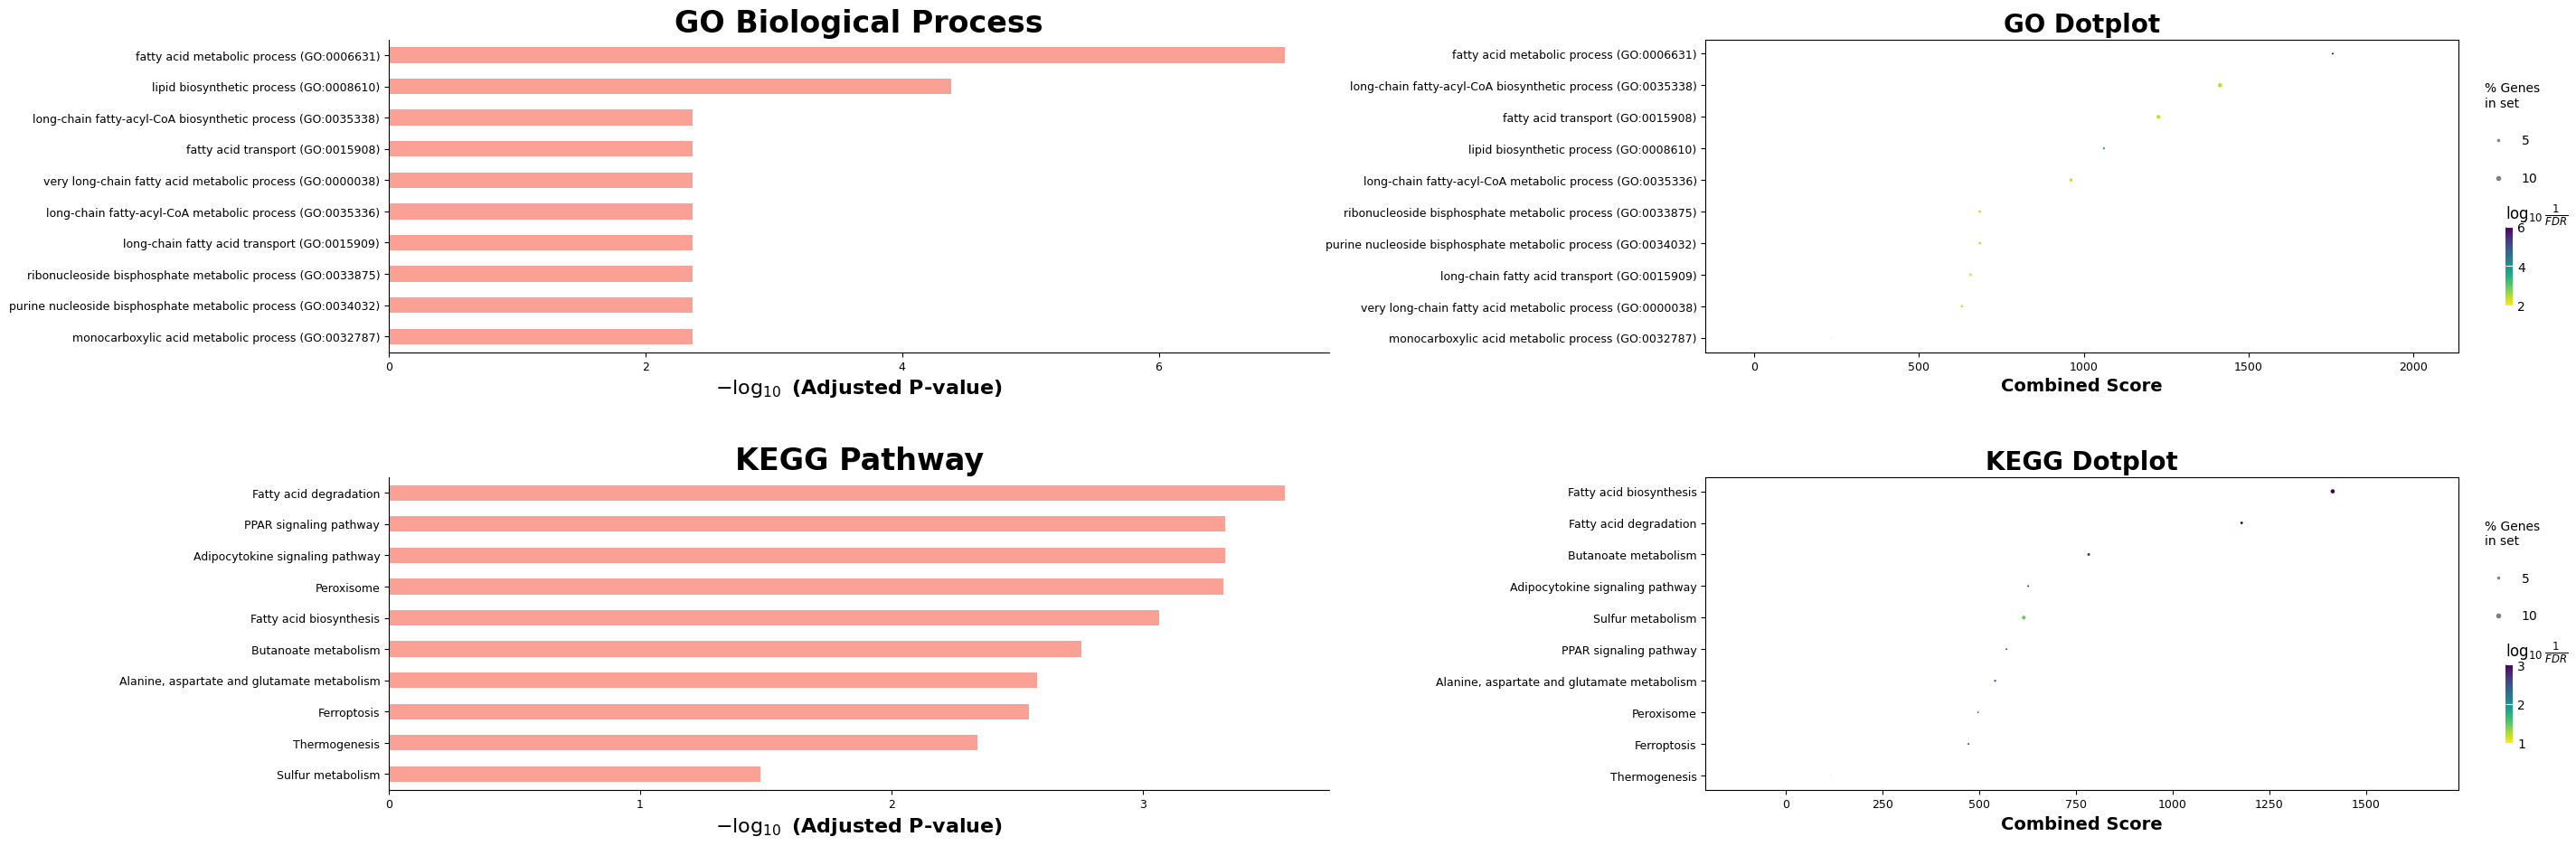

In [ ]:
# GC 결과 시각화

# figure 생성 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(30, 10))

# GO barplot
gp.barplot(
    gc_go_result.res2d,
    title="GO Biological Process",
    cutoff=0.05,
    top_term=10,
    ax=axes[0, 0]
)

# GO dotplot
ax_go = gp.dotplot(
    gc_go_result.res2d,
    title="GO Dotplot",
    cutoff=0.05,
    top_term=10,
    ax=axes[0, 1]
)
ax_go.grid(False)
ax_go.set_axisbelow(False)

# KEGG barplot
gp.barplot(
    gc_kegg_result.res2d,
    title="KEGG Pathway",
    cutoff=0.05,
    top_term=10,
    ax=axes[1, 0]
)

# KEGG dotplot
ax_kegg = gp.dotplot(
    gc_kegg_result.res2d,
    title="KEGG Dotplot",
    cutoff=0.05,
    top_term=10,
    ax=axes[1, 1]
)
ax_kegg.grid(False)
ax_kegg.set_axisbelow(False)

# 레이아웃 겹침 방지
for ax in axes.flat:
    ax.tick_params(labelsize=9)
plt.tight_layout(pad=3.0)   # 여백 크게
plt.subplots_adjust(wspace=0.4, hspace=0.4)

plt.show()

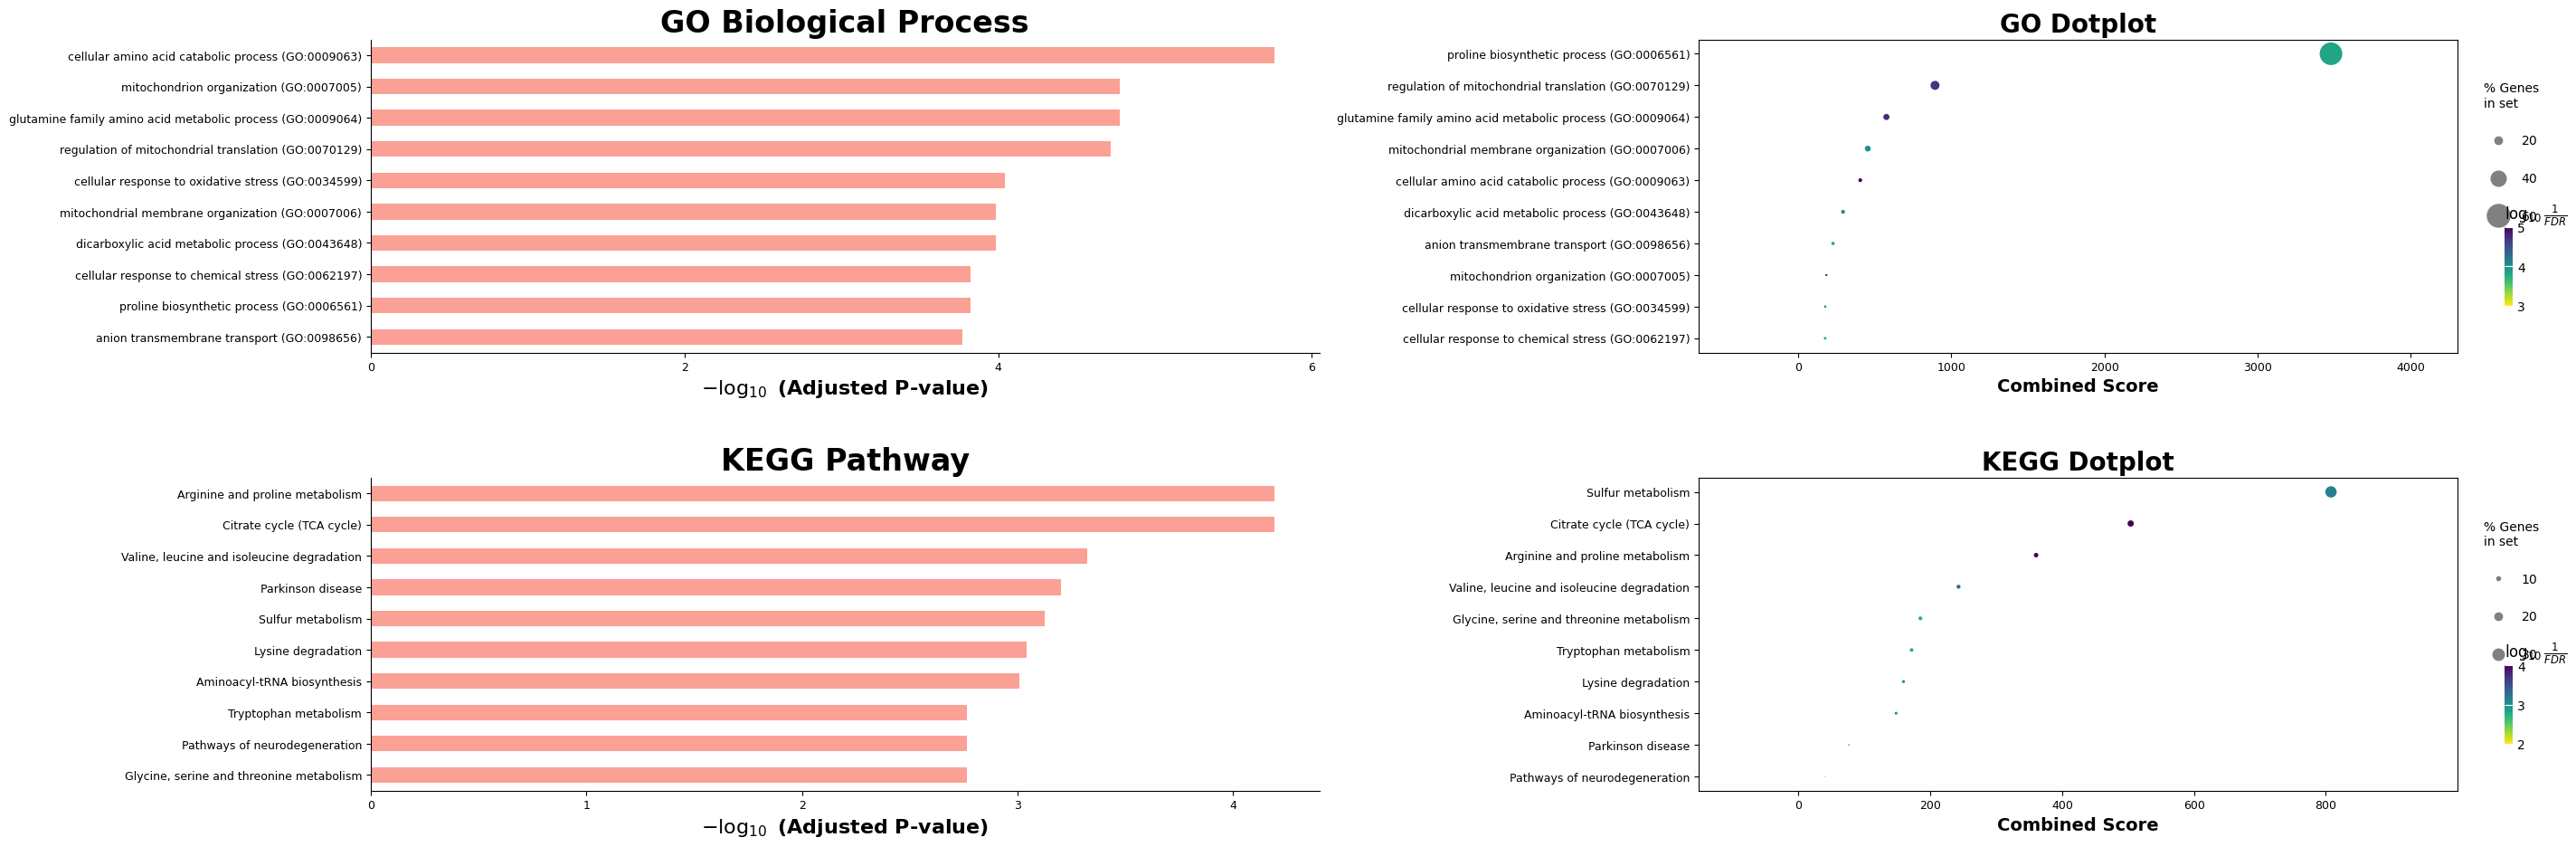

In [ ]:
# GV 결과 시각화

# figure 생성 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(30, 10))

# GO barplot
gp.barplot(
    gv_go_result.res2d,
    title="GO Biological Process",
    cutoff=0.05,
    top_term=10,
    ax=axes[0, 0]
)

# GO dotplot
ax_go = gp.dotplot(
    gv_go_result.res2d,
    title="GO Dotplot",
    cutoff=0.05,
    top_term=10,
    ax=axes[0, 1]
)
ax_go.grid(False)
ax_go.set_axisbelow(False)

# KEGG barplot
gp.barplot(
    gv_kegg_result.res2d,
    title="KEGG Pathway",
    cutoff=0.05,
    top_term=10,
    ax=axes[1, 0]
)

# KEGG dotplot
ax_kegg = gp.dotplot(
    gv_kegg_result.res2d,
    title="KEGG Dotplot",
    cutoff=0.05,
    top_term=10,
    ax=axes[1, 1]
)
ax_kegg.grid(False)
ax_kegg.set_axisbelow(False)

# 레이아웃 겹침 방지
for ax in axes.flat:
    ax.tick_params(labelsize=9)
plt.tight_layout(pad=3.0)   # 여백 크게
plt.subplots_adjust(wspace=0.4, hspace=0.4)

plt.show()

# GSEA

##### GSE138518

In [2]:
# DEG 결과 불러오기
deg_gse138518 = pd.read_csv("GSE138518_DEG_all.csv")

# NaN 제거
deg_gse138518 = deg_gse138518.dropna(subset=["gene", "logFC"])

# gene 중복 제거 (중복 있을 경우 평균)
deg_gse138518 = deg_gse138518.groupby("gene")["logFC"].mean().reset_index()

# ranking 생성
rnk = deg_gse138518.sort_values("logFC", ascending=False)

# 저장 (GSEA 필수 포맷)
rnk[['gene', 'logFC']].to_csv("GSE138518.rnk", sep="\t", index=False, header=False)

In [3]:
# GSEA 실행 (gseapy)
pre_res = gp.prerank(
    rnk="GSE138518.rnk",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2021"
    ],
    organism="human",
    outdir="GSEA_result_GSE138518",
    permutation_num=1000,
    seed=42,
    verbose=True
)

2026-03-25 11:54:43,257 [WARNING] Duplicated values found in preranked stats: 24.82% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-25 11:54:43,258 [INFO] Parsing data files for GSEA.............................
2026-03-25 11:54:43,294 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 11:54:43,301 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 11:54:43,382 [INFO] 3291 gene_sets have been filtered out when max_size=500 and min_size=15
2026-03-25 11:54:43,382 [INFO] 3065 gene_sets used for further statistical testing.....
2026-03-25 11:54:43,382 [INFO] Start to run GSEA...Might take a while..................
2026-03-25 11:57:12,594 [INFO] Congratulations. GSEApy runs successfully................



In [4]:
res = pre_res.res2d
res.to_csv("GSE138518_GSEA_result_summary.csv", index=False)

[<Axes: xlabel='Gene Rank'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>,
 <Axes: ylabel='Ranked metric'>]

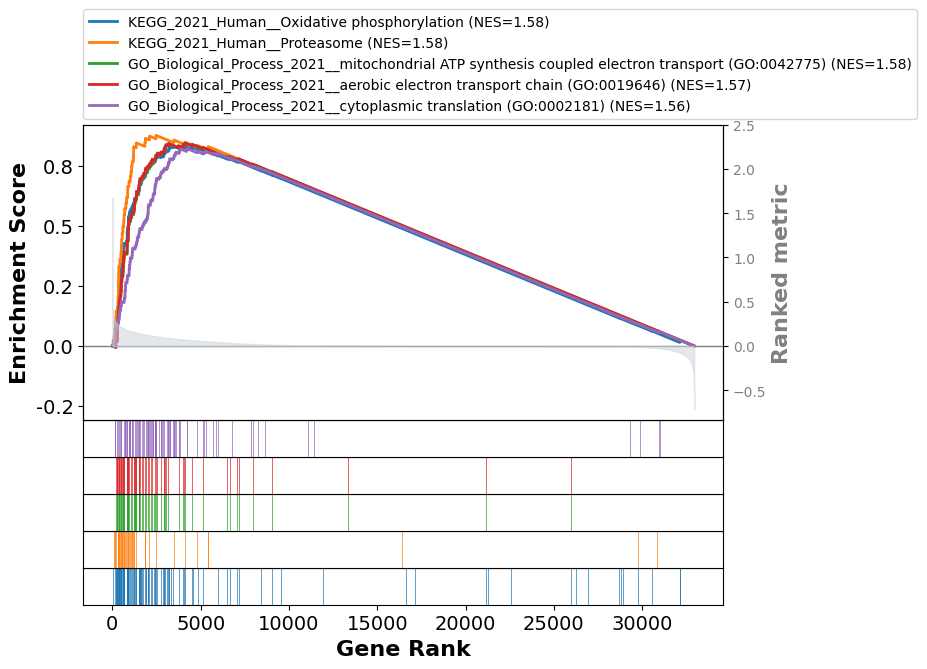

In [ ]:
# 상위 pathway 선택
res = pre_res.res2d
top_terms = res.sort_values("NES", ascending=False).head(5)["Term"].tolist()

# hits / RESs 직접 추출
hits = []
RESs = []

for term in top_terms:
    hits.append(pre_res.results[term]["hits"])
    RESs.append(pre_res.results[term]["RES"])

top_terms = [
    f"{term} (NES={res.loc[res['Term']==term,'NES'].values[0]:.2f})"
    for term in top_terms
]

# 논문 스타일 plot
gp.gseaplot2(
    terms=top_terms,
    hits=hits,
    RESs=RESs,
    rank_metric=pre_res.ranking,
    figsize=(8,6)
)

In [ ]:
res = pre_res.res2d.copy()

# p-value 기준 필터 (추천: FDR)
res_sig = res[res["FDR q-val"] < 0.25]

# up / down 분리
up_pathways = res_sig[res_sig["NES"] > 0].sort_values("NES", ascending=False)
down_pathways = res_sig[res_sig["NES"] < 0].sort_values("NES")

##### GSE155489

In [ ]:
# 사용할 GSEA 찾기
gp.get_library_name(organism="Human")

In [8]:
# GSEA용 ranking 파일 생성

# DEG 결과 불러오기
gv_deg = pd.read_csv("GV_ALL_DEG.csv")
gc_deg = pd.read_csv("GC_ALL_DEG.csv")

# NaN 제거
gv_deg = gv_deg.dropna(subset=["gene", "logFC"])
gc_deg = gc_deg.dropna(subset=["gene", "logFC"])

# gene 중복 제거 (중복 있을 경우 평균)
gv_deg = gv_deg.groupby("gene")["logFC"].mean().reset_index()
gc_deg = gc_deg.groupby("gene")["logFC"].mean().reset_index()

# ranking 생성
gv_rnk = gv_deg.sort_values("logFC", ascending=False)
gc_rnk = gc_deg.sort_values("logFC", ascending=False)

# 저장 (GSEA 필수 포맷)
gv_rnk[['gene', 'logFC']].to_csv("GSE155489_GV.rnk", sep="\t", index=False, header=False)
gc_rnk[['gene', 'logFC']].to_csv("GSE155489_GC.rnk", sep="\t", index=False, header=False)

In [9]:
# GSEA 실행 (gseapy)
gv_pre_res = gp.prerank(
    rnk="GSE155489_GV.rnk",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2021"
    ],
    organism="human",
    outdir="GSEA_result_gv",
    permutation_num=1000,   # 빠르게 테스트용 (나중엔 1000 추천)
    seed=42,
    verbose=True
)
gc_pre_res = gp.prerank(
    rnk="GSE155489_GC.rnk",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2021"
    ],
    organism="human",
    outdir="GSEA_result_gv",
    permutation_num=1000,   # 빠르게 테스트용 (나중엔 1000 추천)
    seed=42,
    verbose=True
)

2026-03-25 11:58:27,666 [WARNING] Duplicated values found in preranked stats: 73.38% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-25 11:58:27,667 [INFO] Parsing data files for GSEA.............................
2026-03-25 11:58:27,727 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 11:58:27,734 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 11:58:27,827 [INFO] 3145 gene_sets have been filtered out when max_size=500 and min_size=15
2026-03-25 11:58:27,829 [INFO] 3211 gene_sets used for further statistical testing.....
2026-03-25 11:58:27,829 [INFO] Start to run GSEA...Might take a while..................
2026-03-25 12:03:05,140 [INFO] Congratulations. GSEApy runs successfully................

2026-03-25 12:03:05,573 [WARNING] Duplicated values found in preranked stats: 73.11% of genes
The order of those genes will

[<Axes: xlabel='Gene Rank'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>,
 <Axes: ylabel='Ranked metric'>]

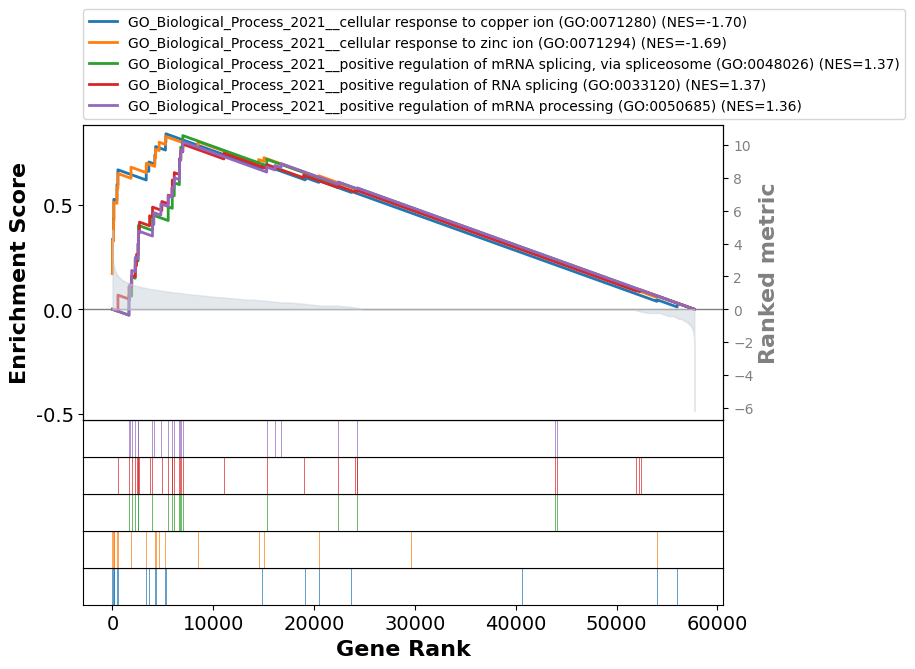

In [ ]:
# 상위 pathway 선택
gv_res = gv_pre_res.res2d
gv_res.to_csv("gv_GSEA_result_summary.csv", index=False)
gv_top_terms = gv_res.sort_values("NES", ascending=False).head(5)["Term"].tolist()

# hits / RESs 직접 추출
gv_hits = []
gv_RESs = []

for term in gv_top_terms:
    gv_hits.append(gv_pre_res.results[term]["hits"])
    gv_RESs.append(gv_pre_res.results[term]["RES"])

gv_labels = [
    f"{term} (NES={res.loc[res['Term']==term,'NES'].values[0]:.2f})"
    for term in gv_top_terms
]

# plot
gp.gseaplot2(
    terms=gv_labels,
    hits=gv_hits,
    RESs=gv_RESs,
    rank_metric=gv_pre_res.ranking,
    figsize=(8,6)
)

[<Axes: xlabel='Gene Rank'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>,
 <Axes: ylabel='Ranked metric'>]

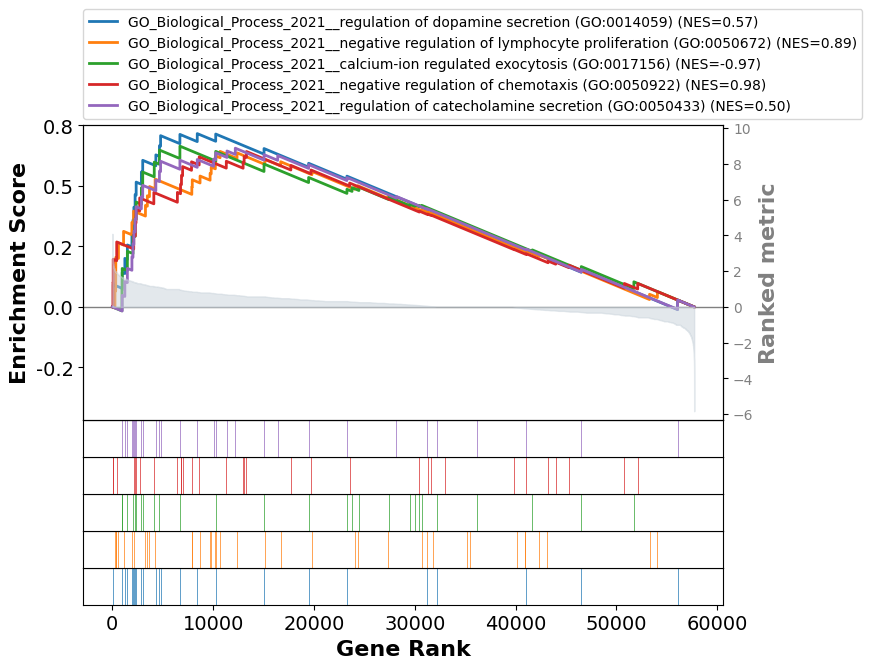

In [ ]:
# 상위 pathway 선택
gc_res = gc_pre_res.res2d
gc_res.to_csv("gc_GSEA_result_summary.csv", index=False)
gc_top_terms = gc_res.sort_values("NES", ascending=False).head(5)["Term"].tolist()

# hits / RESs 직접 추출
gc_hits = []
gc_RESs = []

for term in gc_top_terms:
    gc_hits.append(gc_pre_res.results[term]["hits"])
    gc_RESs.append(gc_pre_res.results[term]["RES"])

gc_labels = [
    f"{term} (NES={res.loc[res['Term']==term,'NES'].values[0]:.2f})"
    for term in gc_top_terms
]

# plot
gp.gseaplot2(
    terms=gc_labels,
    hits=gc_hits,
    RESs=gc_RESs,
    rank_metric=gc_pre_res.ranking,
    figsize=(8,6)
)

##### GC+GV

In [12]:
# DEG 결과 불러오기
deg_gse155489 = pd.read_csv("COMBINED_ALL_DEG.csv")

# NaN 제거
deg_gse155489 = deg_gse155489.dropna(subset=["gene", "logFC"])

# gene 중복 제거 (중복 있을 경우 평균)
deg_gse155489 = deg_gse155489.groupby("gene")["logFC"].mean().reset_index()

# ranking 생성
rnk = deg_gse155489.sort_values("logFC", ascending=False)

# 저장 (GSEA 필수 포맷)
rnk[['gene', 'logFC']].to_csv("GSE155489_ALL.rnk", sep="\t", index=False, header=False)

In [15]:
# GSEA 실행 (gseapy)
pre_res = gp.prerank(
    rnk="GSE138518.rnk",
    gene_sets=[
        "KEGG_2021_Human",
        "GO_Biological_Process_2021"
    ],
    organism="human",
    outdir="GSEA_result_GSE138518",
    permutation_num=1000,   # 빠르게 테스트용 (나중엔 1000 추천)
    seed=42,
    verbose=True
)

2026-03-25 13:08:55,850 [WARNING] Duplicated values found in preranked stats: 24.82% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-25 13:08:55,850 [INFO] Parsing data files for GSEA.............................
2026-03-25 13:08:55,901 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 13:08:55,914 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 13:08:56,020 [INFO] 3291 gene_sets have been filtered out when max_size=500 and min_size=15
2026-03-25 13:08:56,020 [INFO] 3065 gene_sets used for further statistical testing.....
2026-03-25 13:08:56,022 [INFO] Start to run GSEA...Might take a while..................
2026-03-25 13:32:47,456 [INFO] Congratulations. GSEApy runs successfully................



[<Axes: xlabel='Gene Rank'>,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>,
 <Axes: ylabel='Ranked metric'>]

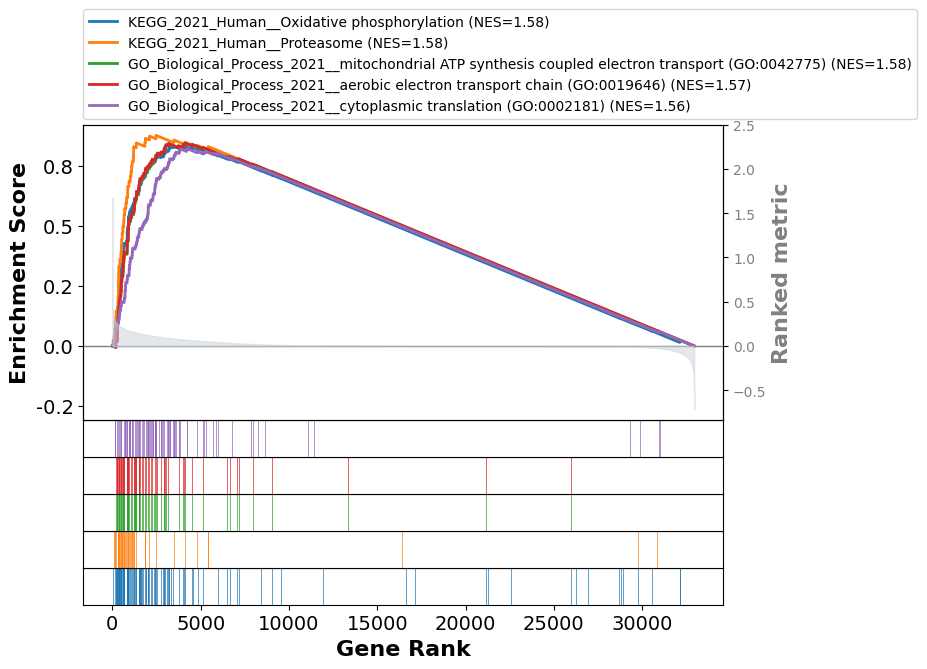

In [ ]:
# 상위 pathway 선택
res = pre_res.res2d
res.to_csv("GSE138518_GSEA_result_summary.csv", index=False)
top_terms = res.sort_values("NES", ascending=False).head(5)["Term"].tolist()

# hits / RESs 직접 추출
hits = []
RESs = []

for term in top_terms:
    hits.append(pre_res.results[term]["hits"])
    RESs.append(pre_res.results[term]["RES"])

labels = [
    f"{term} (NES={res.loc[res['Term']==term,'NES'].values[0]:.2f})"
    for term in top_terms
]

# 논문 스타일 plot
gp.gseaplot2(
    terms=labels,
    hits=hits,
    RESs=RESs,
    rank_metric=pre_res.ranking,
    figsize=(8,6)
)

# GSVA

In [7]:
# 데이터 가져오기 (raw)
gse13818_exp = counts.copy()
gse155489_gv_exp = gv.copy()
gse155489_gc_exp = gc.copy()
gse155489_all_exp = pd.concat([gc, gv], axis=1)

In [8]:
# 데이터 정규화
gse13818_exp = np.log1p(gse13818_exp)
gse155489_gv_exp = np.log1p(gse155489_gv_exp)
gse155489_gc_exp = np.log1p(gse155489_gc_exp)
gse155489_all_exp = np.log1p(gse155489_all_exp)

# gene set 선택
gene_sets = "KEGG_2021_Human"

In [24]:
gsva_res_gse13818 = gp.gsva(
    data=gse13818_exp,              # expression matrix
    gene_sets=gene_sets,    # gmt file
    method='gsva',          # 핵심
    kcdf='Gaussian',        # RNA-seq이면 Gaussian
    min_size=10,
    max_size=500,
    verbose=True
)

2026-03-25 16:43:27,146 [INFO] Parsing data files for GSVA.............................
2026-03-25 16:43:27,162 [INFO] Estimating ECDFs with Gaussian kernels.
2026-03-25 16:43:27,204 [INFO] Enrichr library gene sets already downloaded in: C:\Users\OK\.cache/gseapy, use local file
2026-03-25 16:43:27,223 [INFO] 0009 gene_sets have been filtered out when max_size=500 and min_size=10
2026-03-25 16:43:27,225 [INFO] 0311 gene_sets used for further statistical testing.....
2026-03-25 16:43:27,225 [INFO] Start to run GSVA...Might take a while................
2026-03-25 16:43:27,488 [INFO] Done


In [27]:
df_gse13818 = gsva_res_gse13818.res2d.copy()
df_gse13818["ES"] = pd.to_numeric(df_gse13818["ES"], errors="coerce") # ES를 숫자로 강제 변환
gsva_gse13818 = df_gse13818.pivot(index="Term", columns="Name", values="ES") # Pivot
gsva_gse13818 = gsva_gse13818.fillna(0) # NaN 처리

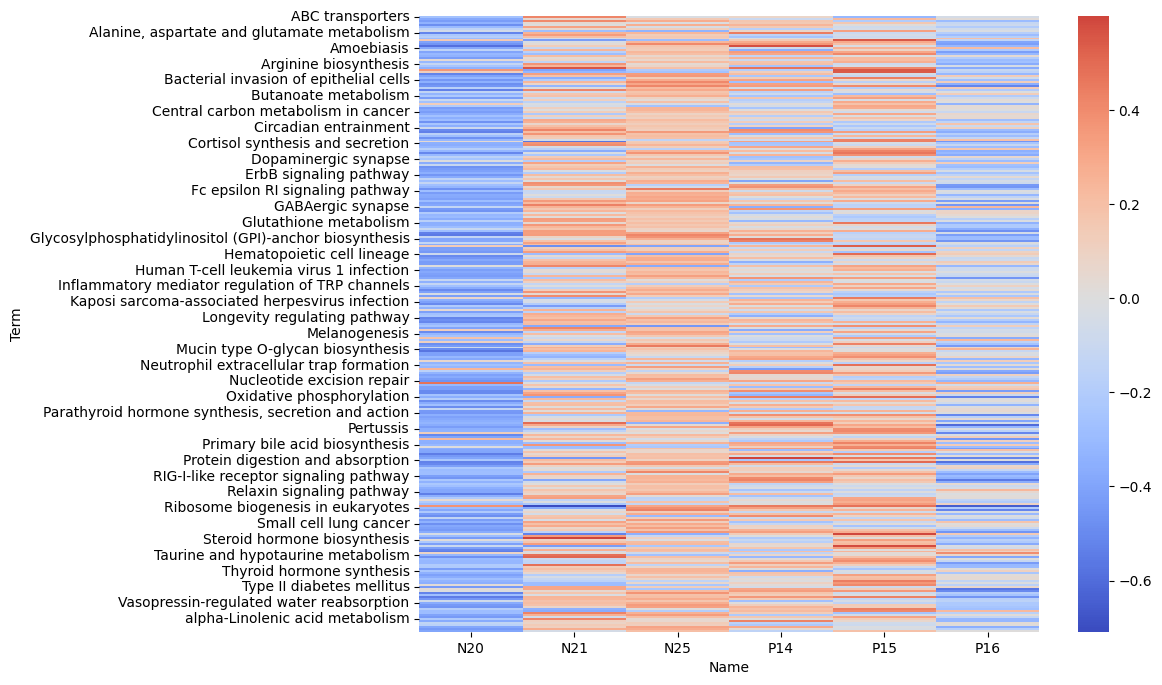

In [28]:
# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(gsva_gse13818, cmap="coolwarm", center=0)
plt.show()